https://www.kaggle.com/code/modeh7/final-solution-ncaa-2025/notebook#%3C%3C--Hardest-difficulty-features--%3E%3E

https://www.kaggle.com/competitions/march-machine-learning-mania-2025/writeups/aziel888-5th-place-solution

https://github.com/fakyras/ncaa_women_2018/blob/master/win_ncaa.R

Strats Left:
- Add feature engineering from above
- hypertune
- ensemble preds

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c march-machine-learning-mania-2026
!unzip /content/march-machine-learning-mania-2026.zip
!rm /content/march-machine-learning-mania-2026.zip

In [2]:
%%capture
# !pip install autogluon.tabular[all]
!pip install optuna

## Import Packages

In [31]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, GammaRegressor, Ridge
from sklearn.metrics import make_scorer, mean_squared_error, roc_auc_score
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingClassifier


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# from keras_tuner import HyperModel
# from keras_tuner import RandomSearch
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras import layers, models

from sklearn.feature_selection import f_classif
from sklearn.metrics import brier_score_loss
from tqdm import tqdm
import statsmodels.api as sm

# from autogluon.tabular import TabularDataset, TabularPredictor

## Load Data

In [4]:
DATA_PATH = ""

# Regular season compact
# m_reg = pd.read_csv(DATA_PATH + "MRegularSeasonCompactResults.csv")
# w_reg = pd.read_csv(DATA_PATH + "WRegularSeasonCompactResults.csv")
m_reg = pd.read_csv(DATA_PATH + "MRegularSeasonDetailedResults.csv")
w_reg = pd.read_csv(DATA_PATH + "WRegularSeasonDetailedResults.csv")

# Tournament compact
# m_tour = pd.read_csv(DATA_PATH + "MNCAATourneyCompactResults.csv")
# w_tour = pd.read_csv(DATA_PATH + "WNCAATourneyCompactResults.csv")
m_tour = pd.read_csv(DATA_PATH + "MNCAATourneyDetailedResults.csv")
w_tour = pd.read_csv(DATA_PATH + "WNCAATourneyDetailedResults.csv")

# Seeds
m_seeds = pd.read_csv(DATA_PATH + "MNCAATourneySeeds.csv")
w_seeds = pd.read_csv(DATA_PATH + "WNCAATourneySeeds.csv")

print("Men Regular:", m_reg.shape)
print("Women Regular:", w_reg.shape)
print("Men Tour:", m_tour.shape)
print("Women Tour:", w_tour.shape)

Men Regular: (122775, 34)
Women Regular: (85505, 34)
Men Tour: (1449, 34)
Women Tour: (961, 34)


In [ ]:
m_reg.columns

Index(['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc',
       'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR',
       'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3',
       'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF'],
      dtype='object')

In [ ]:
m_reg

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,Gender
0,1985,20,1228,81,1328,64,N,0,1
1,1985,25,1106,77,1354,70,H,0,1
2,1985,25,1112,63,1223,56,H,0,1
3,1985,25,1165,70,1432,54,H,0,1
4,1985,25,1192,86,1447,74,H,0,1
...,...,...,...,...,...,...,...,...,...
196818,2026,93,1457,80,1347,78,A,0,1
196819,2026,93,1459,81,1440,67,A,0,1
196820,2026,93,1464,90,1236,61,A,0,1
196821,2026,93,1472,77,1355,62,A,0,1


In [5]:
# Combine men and women
m_reg["Gender"] = 1
w_reg["Gender"] = 0
m_tour["Gender"] = 1
w_tour["Gender"] = 0

m_seeds["Gender"] = 1
w_seeds["Gender"] = 0

reg = pd.concat([m_reg, w_reg], ignore_index=True)
tour = pd.concat([m_tour, w_tour], ignore_index=True)
seeds = pd.concat([m_seeds, w_seeds], ignore_index=True)

print("Combined Regular:", reg.shape)
print("Combined Tour:", tour.shape)

Combined Regular: (208280, 35)
Combined Tour: (2410, 35)


In [7]:
len([
    "Season","DayNum","TeamID","TeamScore","OppID","OppScore","Loc","Gender",
    "FGM","FGA","FGM3","FGA3","FTM","FTA","OR","DR",
    "Ast","TO","Stl","Blk","PF",
    "OppFGM","OppFGA","OppFGM3","OppFGA3","OppFTM","OppFTA","OppOR","OppDR",
    "OppAst","OppTO","OppStl","OppBlk","OppPF"
]), len([
    "Season","DayNum","WTeamID","WScore","LTeamID","LScore","WLoc","Gender",
    "WFGM","WFGA","WFGM3","WFGA3","WFTM","WFTA","WOR","WDR",
    "WAst","WTO","WStl","WBlk","WPF",
    "LFGM","LFGA","LFGM3","LFGA3","LFTM","LFTA","LOR","LDR",
    "LAst","LTO","LStl","LBlk","LPF"
])

(34, 34)

In [10]:
reg["Margin"] = reg["WScore"] - reg["LScore"]

# Winning rows
win_df = reg[[
    "Season","DayNum","WTeamID","WScore","LTeamID","LScore","WLoc","Gender",
    "WFGM","WFGA","WFGM3","WFGA3","WFTM","WFTA","WOR","WDR",
    "WAst","WTO","WStl","WBlk","WPF",
    "LFGM","LFGA","LFGM3","LFGA3","LFTM","LFTA","LOR","LDR",
    "LAst","LTO","LStl","LBlk","LPF"
]].copy()

win_df.columns = [
    "Season","DayNum","TeamID","TeamScore","OppID","OppScore","Loc","Gender",
    "FGM","FGA","FGM3","FGA3","FTM","FTA","OR","DR",
    "Ast","TO","Stl","Blk","PF",
    "OppFGM","OppFGA","OppFGM3","OppFGA3","OppFTM","OppFTA","OppOR","OppDR",
    "OppAst","OppTO","OppStl","OppBlk","OppPF"
]


# Losing rows
loss_df = reg[[
    "Season","DayNum","LTeamID","LScore","WTeamID","WScore","WLoc","Gender",
    "LFGM","LFGA","LFGM3","LFGA3","LFTM","LFTA","LOR","LDR",
    "LAst","LTO","LStl","LBlk","LPF",
    "WFGM","WFGA","WFGM3","WFGA3","WFTM","WFTA","WOR","WDR",
    "WAst","WTO","WStl","WBlk","WPF"
]].copy()

loss_df.columns = win_df.columns

win_df["Win"] = 1
loss_df["Win"] = 0

loss_df["Loc"] = loss_df["Loc"].map({"H":"A","A":"H","N":"N"})

team_games = pd.concat([win_df, loss_df], ignore_index=True)

team_games["Margin"] = team_games["TeamScore"] - team_games["OppScore"]

EPS = 1e-6

# Shooting Efficiency
team_games["FG_pct"] = team_games["FGM"] / (team_games["FGA"] + EPS )
team_games["FG3_pct"] = team_games["FGM3"] / (team_games["FGA3"]+ EPS )
team_games["FT_pct"] = team_games["FTM"] / (team_games["FTA"] + EPS )

team_games["eFG_pct"] = (team_games["FGM"] + 0.5 * team_games["FGM3"]) / (team_games["FGA"]  + EPS )

# Possessions (Dean Oliver Formula)
team_games["Poss"] = (
    team_games["FGA"]
    - team_games["OR"]
    + team_games["TO"]
    + 0.475 * team_games["FTA"]
)

# Offensive / Defensive Rating
team_games["OffRtg"] = 100 * team_games["TeamScore"] / (team_games["Poss"]  + EPS )
team_games["DefRtg"] = 100 * team_games["OppScore"] / (team_games["Poss"] + EPS )
team_games["NetRtg"] = team_games["OffRtg"] - team_games["DefRtg"]

# Four Factors
team_games["TOV_pct"] = team_games["TO"] / (team_games["Poss"]  + EPS )
team_games["ORB_pct"] = team_games["OR"] / (team_games["OR"] + team_games["OppDR"] + EPS )
team_games["FTR"] = team_games["FTA"] / (team_games["FGA"]  + EPS )

team_games.head()

,Season,DayNum,TeamID,TeamScore,OppID,OppScore,Loc,Gender,FGM,FGA,...,FG3_pct,FT_pct,eFG_pct,Poss,OffRtg,DefRtg,NetRtg,TOV_pct,ORB_pct,FTR
0,2003,10,1104,68,1328,62,N,1,27,58,...,0.214286,0.611111,0.491379,75.550,90.006617,82.064857,7.941760,0.304434,0.388889,0.310345
1,2003,10,1272,70,1393,63,N,1,26,62,...,0.400000,0.526316,0.483871,69.025,101.412530,91.271277,10.141253,0.188338,0.375000,0.306452
2,2003,11,1266,73,1437,61,N,1,24,58,...,0.444444,0.586207,0.482759,64.775,112.697798,94.172133,18.525665,0.154381,0.435897,0.500000
3,2003,11,1296,56,1457,50,N,1,18,38,...,0.333333,0.548387,0.513158,58.725,95.359726,85.142612,10.217113,0.204342,0.230769,0.815789
4,2003,11,1400,77,1208,71,N,1,30,61,...,0.428571,0.846154,0.540984,64.175,119.984416,110.634981,9.349435,0.218153,0.531250,0.213115


In [12]:
# Season Level Stats
season_stats = (
    team_games
    .groupby(["Season","TeamID","Gender"])
    .agg(
        games=("Win","count"),
        win_pct=("Win","mean"),
        avg_margin=("Margin","mean"),

        OffRtg=("OffRtg","mean"),
        DefRtg=("DefRtg","mean"),
        NetRtg=("NetRtg","mean"),

        eFG_pct=("eFG_pct","mean"),
        FG3_pct=("FG3_pct","mean"),
        FT_pct=("FT_pct","mean"),

        TOV_pct=("TOV_pct","mean"),
        ORB_pct=("ORB_pct","mean"),
        FTR=("FTR","mean")
    )
    .reset_index()
)

season_stats.head()

,Season,TeamID,Gender,games,win_pct,avg_margin,OffRtg,DefRtg,NetRtg,eFG_pct,FG3_pct,FT_pct,TOV_pct,ORB_pct,FTR
0,2003,1102,1,28,0.428571,0.250000,103.754715,103.430089,0.324626,0.584407,0.367637,0.642402,0.205098,0.168235,0.446693
1,2003,1103,1,27,0.481481,0.629630,110.565131,110.240730,0.324401,0.536564,0.331990,0.735271,0.179353,0.305803,0.465135
2,2003,1104,1,28,0.607143,4.285714,103.369972,97.565123,5.804850,0.475785,0.325442,0.705168,0.199076,0.371256,0.372350
3,2003,1105,1,26,0.269231,-4.884615,92.999173,99.549874,-6.550701,0.457983,0.359630,0.709598,0.240928,0.335166,0.359501
4,2003,1106,1,28,0.464286,-0.142857,93.648219,94.062220,-0.414001,0.481697,0.350196,0.623158,0.250859,0.349480,0.307563


In [13]:
# Add Seed Numbers
seeds["SeedNum"] = seeds["Seed"].str[1:3].astype(int)

seeds.head()

,Season,Seed,TeamID,Gender,SeedNum
0,1985,W01,1207,1,1
1,1985,W02,1210,1,2
2,1985,W03,1228,1,3
3,1985,W04,1260,1,4
4,1985,W05,1374,1,5


In [14]:
season_stats = season_stats.merge(
    seeds,
    on=["Season","TeamID","Gender"],
    how="left"
)

season_stats.head()

,Season,TeamID,Gender,games,win_pct,avg_margin,OffRtg,DefRtg,NetRtg,eFG_pct,FG3_pct,FT_pct,TOV_pct,ORB_pct,FTR,Seed,SeedNum
0,2003,1102,1,28,0.428571,0.250000,103.754715,103.430089,0.324626,0.584407,0.367637,0.642402,0.205098,0.168235,0.446693,NaN,NaN
1,2003,1103,1,27,0.481481,0.629630,110.565131,110.240730,0.324401,0.536564,0.331990,0.735271,0.179353,0.305803,0.465135,NaN,NaN
2,2003,1104,1,28,0.607143,4.285714,103.369972,97.565123,5.804850,0.475785,0.325442,0.705168,0.199076,0.371256,0.372350,Y10,10.0
3,2003,1105,1,26,0.269231,-4.884615,92.999173,99.549874,-6.550701,0.457983,0.359630,0.709598,0.240928,0.335166,0.359501,NaN,NaN
4,2003,1106,1,28,0.464286,-0.142857,93.648219,94.062220,-0.414001,0.481697,0.350196,0.623158,0.250859,0.349480,0.307563,NaN,NaN


In [22]:
df = tour.copy()

df["Team1"] = df[["WTeamID","LTeamID"]].min(axis=1)
df["Team2"] = df[["WTeamID","LTeamID"]].max(axis=1)

df["Target"] = (df["WTeamID"] == df["Team1"]).astype(int)

df = df[["Season","Gender","Team1","Team2","Target"]]

In [23]:
# Create copies with prefixed columns
t1_stats = season_stats.copy()
t2_stats = season_stats.copy()

# Rename only feature columns
feature_cols = ["games", "win_pct",
    "avg_margin",
    "OffRtg",
    "DefRtg",
    "NetRtg",
    "eFG_pct",
    "FG3_pct",
    "FT_pct",
    "TOV_pct",
    "ORB_pct",
    "FTR",
    "SeedNum"]

t1_stats = t1_stats.rename(
    columns={col: f"T1_{col}" for col in feature_cols}
)

t2_stats = t2_stats.rename(
    columns={col: f"T2_{col}" for col in feature_cols}
)


df = df.merge(
    t1_stats,
    left_on=["Season","Team1","Gender"],
    right_on=["Season","TeamID","Gender"],
    how="left"
)

df = df.drop(columns=["TeamID"])

df = df.merge(
    t2_stats,
    left_on=["Season","Team2","Gender"],
    right_on=["Season","TeamID","Gender"],
    how="left"
)

df = df.drop(columns=["TeamID"])

In [25]:
features = [
    "win_pct",
    "avg_margin",
    "OffRtg",
    "DefRtg",
    "NetRtg",
    "eFG_pct",
    "FG3_pct",
    "FT_pct",
    "TOV_pct",
    "ORB_pct",
    "FTR",
    "SeedNum"
]

for col in features:
    df[col + "_diff"] = df["T1_" + col] - df["T2_" + col]

In [29]:
# Elo Implementation
regular_data = reg.copy()

# Standardize names
regular_data["T1_TeamID"] = regular_data["WTeamID"]
regular_data["T2_TeamID"] = regular_data["LTeamID"]
regular_data["win"] = 1

# Define Elo Functions
base_elo = 1000
elo_width = 400
k_factor = 20  # 100 is very aggressive; 20–30 is usually more stable

def expected_result(elo_a, elo_b):
    return 1.0 / (1 + 10 ** ((elo_b - elo_a) / elo_width))

def update_elo(winner_elo, loser_elo):
    expected_win = expected_result(winner_elo, loser_elo)
    change = k_factor * (1 - expected_win)
    return winner_elo + change, loser_elo - change

# Compute Season Elo
elos = []

for season in sorted(regular_data["Season"].unique()):
    ss = regular_data[regular_data["Season"] == season]

    teams = set(ss["T1_TeamID"]) | set(ss["T2_TeamID"])
    elo_dict = {team: base_elo for team in teams}

    for _, row in ss.iterrows():
        w = row["T1_TeamID"]
        l = row["T2_TeamID"]

        w_elo, l_elo = elo_dict[w], elo_dict[l]
        w_new, l_new = update_elo(w_elo, l_elo)

        elo_dict[w] = w_new
        elo_dict[l] = l_new

    season_elo = pd.DataFrame({
        "TeamID": list(elo_dict.keys()),
        "elo": list(elo_dict.values())
    })
    season_elo["Season"] = season
    elos.append(season_elo)

elos = pd.concat(elos, ignore_index=True)

# Merge Into Tournament Data
elos_T1 = elos.rename(columns={"TeamID":"Team1","elo":"T1_elo"})
elos_T2 = elos.rename(columns={"TeamID":"Team2","elo":"T2_elo"})

df = df.merge(elos_T1, on=["Season","Team1"], how="left")
df = df.merge(elos_T2, on=["Season","Team2"], how="left")

df["elo_diff"] = df["T1_elo"] - df["T2_elo"]

In [33]:
# Point Diff FE
dt = reg.copy()

dt["PointDiff"] = dt["WScore"] - dt["LScore"]
dt["T1_TeamID"] = dt["WTeamID"].astype(str)
dt["T2_TeamID"] = dt["LTeamID"].astype(str)

# Fit Season-by-Season Model
glm_quality = []

for season in tqdm(sorted(dt["Season"].unique())):
    data_season = dt[dt["Season"] == season]

    formula = "PointDiff ~ -1 + C(T1_TeamID) + C(T2_TeamID)"

    model = sm.GLM.from_formula(
        formula=formula,
        data=data_season,
        family=sm.families.Gaussian()
    ).fit()

    params = model.params.reset_index()
    params.columns = ["TeamParam","quality"]

    # Keep only T1 terms
    params = params[params["TeamParam"].str.contains("T1_TeamID")]

    params["TeamID"] = params["TeamParam"].str.extract(r'\[(.*?)\]')
    params["TeamID"] = params["TeamID"].astype(int)
    params["Season"] = season

    glm_quality.append(params[["Season","TeamID","quality"]])

glm_quality = pd.concat(glm_quality, ignore_index=True)

# Merge Into Tournament
q_T1 = glm_quality.rename(columns={
    "TeamID":"Team1",
    "quality":"T1_quality"
})

q_T2 = glm_quality.rename(columns={
    "TeamID":"Team2",
    "quality":"T2_quality"
})

df = df.merge(q_T1, on=["Season","Team1"], how="left")
df = df.merge(q_T2, on=["Season","Team2"], how="left")

df["quality_diff"] = df["T1_quality"] - df["T2_quality"]

100%|██████████| 24/24 [15:08<00:00, 37.86s/it]


In [34]:
df

,Season,Gender,Team1,Team2,Target,T1_games,T1_win_pct,T1_avg_margin,T1_OffRtg,T1_DefRtg,...,FTR_diff,SeedNum_diff,Era_PaceUp,Era_Modern,T1_elo,T2_elo,elo_diff,T1_quality,T2_quality,quality_diff
0,2003,1,1411,1421,0,30,0.600000,1.966667,102.899750,100.868566,...,0.152277,0.0,1,0,1021.614188,984.107429,37.506758,1.035877,-4.178432,5.214309
1,2003,1,1112,1436,1,28,0.892857,14.964286,110.623625,91.312811,...,0.031691,-15.0,1,0,1165.441864,1063.161687,102.280177,19.815587,6.567599,13.247987
2,2003,1,1113,1272,1,29,0.620690,6.793103,109.231054,99.270460,...,0.071937,3.0,1,0,1059.617126,1130.639219,-71.022093,18.748413,14.335417,4.412996
3,2003,1,1141,1166,1,29,0.793103,6.103448,109.557598,101.204523,...,0.127689,5.0,1,0,1129.153011,1164.373624,-35.220613,9.532961,16.971303,-7.438342
4,2003,1,1143,1301,1,29,0.724138,4.724138,105.227021,98.616160,...,-0.039185,-1.0,1,0,1086.569149,1058.208012,28.361137,10.495808,16.006376,-5.510567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2405,2025,0,3163,3425,1,34,0.911765,28.970588,115.826715,74.068301,...,-0.143791,1.0,0,1,1215.823608,1207.168538,8.655070,36.421421,30.631347,5.790074
2406,2025,0,3395,3400,0,34,0.911765,20.294118,112.607634,83.449539,...,-0.100395,1.0,0,1,1213.742469,1223.516346,-9.773878,27.260567,34.130703,-6.870136
2407,2025,0,3163,3417,1,34,0.911765,28.970588,115.826715,74.068301,...,-0.072532,1.0,0,1,1215.823608,1225.821105,-9.997497,36.421421,29.769222,6.652199
2408,2025,0,3376,3400,1,33,0.909091,22.727273,109.352990,78.738703,...,-0.085405,0.0,0,1,1221.744450,1223.516346,-1.771897,36.416777,34.130703,2.286073


In [35]:
def assign_era(season):
    """
    Season refers to tournament year (e.g. 2015 = 2014-15 season)
    """
    if season <= 1990:
        return "GameChangers"
    elif season <= 2018:
        return "PaceUp"
    else:
        return "Modern"

# Apply to tournament dataset
df["Era"] = df["Season"].apply(assign_era)

# OHE
df["Era_PaceUp"] = 0
df["Era_Modern"] = 0
df.loc[df["Era"] == "PaceUp", "Era_PaceUp"] = 1
df.loc[df["Era"] == "Modern", "Era_Modern"] = 1
df = df.drop(columns=["Era"])

In [36]:
df.columns

Index(['Season', 'Gender', 'Team1', 'Team2', 'Target', 'T1_games',
       'T1_win_pct', 'T1_avg_margin', 'T1_OffRtg', 'T1_DefRtg', 'T1_NetRtg',
       'T1_eFG_pct', 'T1_FG3_pct', 'T1_FT_pct', 'T1_TOV_pct', 'T1_ORB_pct',
       'T1_FTR', 'Seed_x', 'T1_SeedNum', 'T2_games', 'T2_win_pct',
       'T2_avg_margin', 'T2_OffRtg', 'T2_DefRtg', 'T2_NetRtg', 'T2_eFG_pct',
       'T2_FG3_pct', 'T2_FT_pct', 'T2_TOV_pct', 'T2_ORB_pct', 'T2_FTR',
       'Seed_y', 'T2_SeedNum', 'win_pct_diff', 'avg_margin_diff',
       'OffRtg_diff', 'DefRtg_diff', 'NetRtg_diff', 'eFG_pct_diff',
       'FG3_pct_diff', 'FT_pct_diff', 'TOV_pct_diff', 'ORB_pct_diff',
       'FTR_diff', 'SeedNum_diff', 'Era_PaceUp', 'Era_Modern', 'T1_elo',
       'T2_elo', 'elo_diff', 'T1_quality', 'T2_quality', 'quality_diff'],
      dtype='object')

## EDA

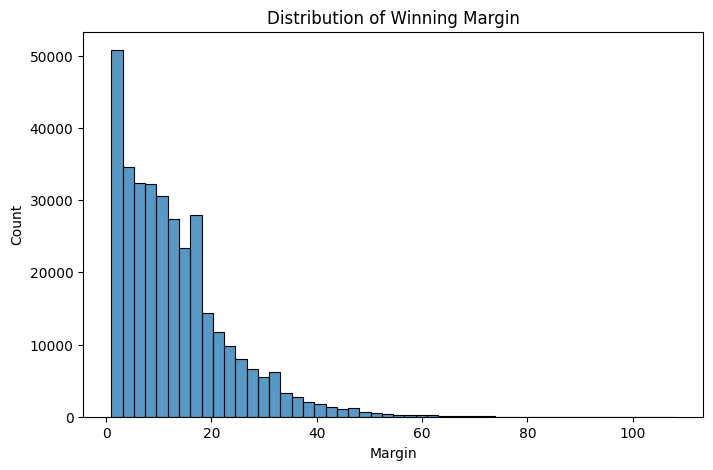

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(reg["Margin"], bins=50)
plt.title("Distribution of Winning Margin")
plt.show()

## HGBG

In [81]:
X_cols = [ 'Gender',
       'T1_win_pct', 'T1_avg_margin', 'T1_OffRtg', 'T1_DefRtg', 'T1_NetRtg',
       'T1_eFG_pct', 'T1_FG3_pct', 'T1_FT_pct', 'T1_TOV_pct', 'T1_ORB_pct',
       'T1_FTR',   'T2_games', 'T2_win_pct',
       'T2_avg_margin', 'T2_OffRtg', 'T2_DefRtg', 'T2_NetRtg', 'T2_eFG_pct',
       'T2_FG3_pct', 'T2_FT_pct', 'T2_TOV_pct', 'T2_ORB_pct', 'T2_FTR',
        'win_pct_diff', 'avg_margin_diff',
       'OffRtg_diff', 'DefRtg_diff', 'NetRtg_diff', 'eFG_pct_diff',
       'FG3_pct_diff', 'FT_pct_diff', 'TOV_pct_diff', 'ORB_pct_diff',
       'FTR_diff', 'SeedNum_diff', 'Era_PaceUp', 'Era_Modern', 'T1_elo',
       'T2_elo', 'elo_diff', 'T1_quality', 'T2_quality', 'quality_diff']

In [75]:
X_cols = [c for c in df.columns if c.endswith("_diff")] + ["Gender", 'Era_PaceUp',	'Era_Modern']
X_cols

['win_pct_diff',
 'avg_margin_diff',
 'OffRtg_diff',
 'DefRtg_diff',
 'NetRtg_diff',
 'eFG_pct_diff',
 'FG3_pct_diff',
 'FT_pct_diff',
 'TOV_pct_diff',
 'ORB_pct_diff',
 'FTR_diff',
 'SeedNum_diff',
 'elo_diff',
 'quality_diff',
 'Gender',
 'Era_PaceUp',
 'Era_Modern']

In [87]:
# Ai pref
X_cols = [
    "avg_margin_diff",
    "OffRtg_diff",
    "DefRtg_diff",
    "NetRtg_diff",
    "eFG_pct_diff",
    "TOV_pct_diff",
    "ORB_pct_diff",
    "FTR_diff",
    "SeedNum_diff",
    "elo_diff",
    "quality_diff"
]+ ["Gender", 'Era_PaceUp',	'Era_Modern']

X_cols = ['win_pct_diff',
 'avg_margin_diff',
 'OffRtg_diff',
 'DefRtg_diff',
 'NetRtg_diff',
 'eFG_pct_diff',
 'FG3_pct_diff',
 'FT_pct_diff',
 'TOV_pct_diff',
 'ORB_pct_diff',
 'FTR_diff',
#  'SeedNum_diff',
 'elo_diff',
 'quality_diff',
 'Gender',
 'Era_PaceUp',
 'Era_Modern']
X_cols

['win_pct_diff',
 'avg_margin_diff',
 'OffRtg_diff',
 'DefRtg_diff',
 'NetRtg_diff',
 'eFG_pct_diff',
 'FG3_pct_diff',
 'FT_pct_diff',
 'TOV_pct_diff',
 'ORB_pct_diff',
 'FTR_diff',
 'elo_diff',
 'quality_diff',
 'Gender',
 'Era_PaceUp',
 'Era_Modern']

In [88]:
# Years to leave out as validation one at a time
val_years = [2019, 2021, 2022, 2023, 2024, 2025]

brier_scores = []

for val_year in tqdm(val_years, desc="LOSO CV Seasons"):
    # Train on all previous seasons
    train_mask = df["Season"] < val_year
    val_mask   = df["Season"] == val_year

    X_train = df.loc[train_mask, X_cols]
    y_train = df.loc[train_mask, "Target"]

    X_val   = df.loc[val_mask, X_cols]
    y_val   = df.loc[val_mask, "Target"]

    # Fit model
    model = HistGradientBoostingClassifier(
        loss="log_loss",
        # max_depth=6,
        # learning_rate=0.05,
        # max_iter=500,
        random_state=31
    )

    model.fit(X_train, y_train)

    # Predict
    pred_val = model.predict_proba(X_val)[:,1]

    # Compute Brier score
    brier = brier_score_loss(y_val, pred_val)
    brier_scores.append((val_year, brier))

    # Optional: can print per season if you want more verbose
    print(f"Season {val_year}: Brier Score = {brier:.4f}")

# Summary
avg_brier = np.mean([b for _, b in brier_scores])
print("\nAverage Brier score 2019-2025:", round(avg_brier,4))

LOSO CV Seasons:  17%|█▋        | 1/6 [00:00<00:01,  2.95it/s]

Season 2019: Brier Score = 0.1751


LOSO CV Seasons:  33%|███▎      | 2/6 [00:00<00:01,  2.25it/s]

Season 2021: Brier Score = 0.2350


LOSO CV Seasons:  50%|█████     | 3/6 [00:01<00:01,  2.05it/s]

...

Season 2023: Brier Score = 0.2136


LOSO CV Seasons:  83%|████████▎ | 5/6 [00:02<00:00,  1.89it/s]

Season 2024: Brier Score = 0.2053


LOSO CV Seasons: 100%|██████████| 6/6 [00:03<00:00,  1.94it/s]

Season 2025: Brier Score = 0.1546

Average Brier score 2019-2025: 0.1978


In [89]:
# --- Final Model Training ---
print("\nTraining final model on all available data (through 2026)...")
X_all = df[X_cols]
y_all = df["Target"]

model = HistGradientBoostingClassifier(
    loss="log_loss",
    random_state=31
)

model.fit(X_all, y_all)


Training final model on all available data (through 2026)...


HistGradientBoostingClassifier(random_state=31)

In [90]:
# Load sample submission
sub = pd.read_csv("/content/SampleSubmissionStage1.csv")

sub[["Season","Team1","Team2"]] = sub["ID"].str.split("_", expand=True)
sub["Season"] = sub["Season"].astype(int)
sub["Team1"]  = sub["Team1"].astype(int)
sub["Team2"]  = sub["Team2"].astype(int)

# Era one-hot (k-1)
sub["Era_PaceUp"]  = (sub["Season"].apply(assign_era) == "PaceUp").astype(int)
sub["Era_Modern"]  = (sub["Season"].apply(assign_era) == "Modern").astype(int)

# Merge T1/T2 stats (diff features)
t1_stats = season_stats.rename(columns={col: f"T1_{col}" for col in feature_cols})
t2_stats = season_stats.rename(columns={col: f"T2_{col}" for col in feature_cols})

sub = sub.merge(
    t1_stats,
    left_on=["Season","Team1"],
    right_on=["Season","TeamID"],
    how="left"
).drop(columns=["TeamID"])

sub = sub.merge(
    t2_stats,
    left_on=["Season","Team2"],
    right_on=["Season","TeamID"],
    how="left"
).drop(columns=["TeamID"])

# # --- Merge seeds ---
# seeds_T1 = seeds[["Season","TeamID","SeedNum"]].rename(
#     columns={"TeamID":"Team1","SeedNum":"T1_SeedNum"}
# )

# seeds_T2 = seeds[["Season","TeamID","SeedNum"]].rename(
#     columns={"TeamID":"Team2","SeedNum":"T2_SeedNum"}
# )

# sub = sub.merge(seeds_T1, on=["Season","Team1"], how="left")
# sub = sub.merge(seeds_T2, on=["Season","Team2"], how="left")

sub["seed_diff"] = sub["T1_SeedNum"] - sub["T2_SeedNum"]

elos_T1 = elos.rename(columns={
    "TeamID":"Team1",
    "elo":"T1_elo"
})

elos_T2 = elos.rename(columns={
    "TeamID":"Team2",
    "elo":"T2_elo"
})

sub = sub.merge(elos_T1, on=["Season","Team1"], how="left")
sub = sub.merge(elos_T2, on=["Season","Team2"], how="left")

sub["elo_diff"] = sub["T1_elo"] - sub["T2_elo"]

glm_T1 = glm_quality.rename(columns={
    "TeamID":"Team1",
    "quality":"T1_quality"
})

glm_T2 = glm_quality.rename(columns={
    "TeamID":"Team2",
    "quality":"T2_quality"
})

sub = sub.merge(glm_T1, on=["Season","Team1"], how="left")
sub = sub.merge(glm_T2, on=["Season","Team2"], how="left")

sub["quality_diff"] = sub["T1_quality"] - sub["T2_quality"]

for col in feature_cols:
    sub[f"{col}_diff"] = sub[f"T1_{col}"] - sub[f"T2_{col}"]

sub['Gender'] = sub.filter(like = 'Gender').mean(axis = 1).astype(int)

# Final features for prediction
X_sub = X_cols

# --- Predict using your already trained model ---
sub["Pred"] = model.predict_proba(sub[X_sub])[:,1]  # <--- reuse the CV/final model

In [48]:
sub.isna().sum()

,0
ID,0
Pred,0
Season,0
Team1,0
Team2,0
Era_PaceUp,0
Era_Modern,0
Gender_x,0
T1_games,0
T1_win_pct,0


In [ ]:
# Post Processing
sub["Pred"] = sub["Pred"].clip(0.025, 0.975)


# MEN ONLY (Gender == 1)
mask_m = sub["Gender"] == 1

sub.loc[mask_m & (sub["T1_SeedNum"] == 16) & (sub["T2_SeedNum"] == 1), "Pred"] = 0
sub.loc[mask_m & (sub["T1_SeedNum"] == 15) & (sub["T2_SeedNum"] == 2), "Pred"] = 0
sub.loc[mask_m & (sub["T1_SeedNum"] == 14) & (sub["T2_SeedNum"] == 3), "Pred"] = 0
sub.loc[mask_m & (sub["T1_SeedNum"] == 13) & (sub["T2_SeedNum"] == 4), "Pred"] = 0

sub.loc[mask_m & (sub["T1_SeedNum"] == 1) & (sub["T2_SeedNum"] == 16), "Pred"] = 1
sub.loc[mask_m & (sub["T1_SeedNum"] == 2) & (sub["T2_SeedNum"] == 15), "Pred"] = 1
sub.loc[mask_m & (sub["T1_SeedNum"] == 3) & (sub["T2_SeedNum"] == 14), "Pred"] = 1
sub.loc[mask_m & (sub["T1_SeedNum"] == 4) & (sub["T2_SeedNum"] == 13), "Pred"] = 1


# WOMEN ONLY (Gender == 0)
mask_w = sub["Gender"] == 0

sub.loc[mask_w & (sub["T1_SeedNum"] == 16) & (sub["T2_SeedNum"] == 1), "Pred"] = 0
sub.loc[mask_w & (sub["T1_SeedNum"] == 15) & (sub["T2_SeedNum"] == 2), "Pred"] = 0
sub.loc[mask_w & (sub["T1_SeedNum"] == 14) & (sub["T2_SeedNum"] == 3), "Pred"] = 0
sub.loc[mask_w & (sub["T1_SeedNum"] == 13) & (sub["T2_SeedNum"] == 4), "Pred"] = 0

sub.loc[mask_w & (sub["T1_SeedNum"] == 1) & (sub["T2_SeedNum"] == 16), "Pred"] = 1
sub.loc[mask_w & (sub["T1_SeedNum"] == 2) & (sub["T2_SeedNum"] == 15), "Pred"] = 1
sub.loc[mask_w & (sub["T1_SeedNum"] == 3) & (sub["T2_SeedNum"] == 14), "Pred"] = 1
sub.loc[mask_w & (sub["T1_SeedNum"] == 4) & (sub["T2_SeedNum"] == 13), "Pred"] = 1

In [91]:
sub[["ID","Pred"]].to_csv('/content/drive/MyDrive/Output/sub.csv', index=False)

In [92]:
!kaggle competitions submit -c march-machine-learning-mania-2026 -f /content/drive/MyDrive/Output/sub.csv -m "afe v3 no seed diff"

100% 17.1M/17.1M [00:00<00:00, 45.3MB/s]
400 Client Error: Bad Request for url: https://www.kaggle.com/api/v1/competitions/submissions/submit/march-machine-learning-mania-2026


## Save to Github

In [ ]:
!git config --global user.email "abishpius@gmail.com"
!git config --global user.name "Abish Pius"

In [ ]:
from google.colab import userdata
import requests

token = userdata.get('github')
repo_name = "March-Madness-2026"
username = "abishpius"
message = "Kaggle Competition March Madness 2026"
notebook_name = "Kaggle_March_Madness_Advanced_FE.ipynb"

headers = {
    "Authorization": f"token {token}",
    "Accept": "application/vnd.github+json"
}

# === CHECK IF REPO EXISTS ===
check_url = f"https://api.github.com/repos/{username}/{repo_name}"
check_resp = requests.get(check_url, headers=headers)

if check_resp.status_code == 200:
    print(f"❌ Repo '{repo_name}' already exists at: https://github.com/{username}/{repo_name}")
else:
    # === CREATE REPO ===
    create_url = "https://api.github.com/user/repos"
    payload = {
        "name": repo_name,
        "auto_init": True,
        "private": False  # change to True if you want a private repo
    }

    create_resp = requests.post(create_url, headers=headers, json=payload)

    if create_resp.status_code == 201:
        print(f"✅ Repo '{repo_name}' created successfully.")

        # === UPDATE README.md ===
        import base64

        update_url = f"https://api.github.com/repos/{username}/{repo_name}/contents/README.md"
        readme_text = ""
        encoded = base64.b64encode(readme_text.encode()).decode()
        update_payload = {
            "message": message,
            "content": encoded,
            "sha": requests.get(update_url, headers=headers).json()["sha"]
        }

        update_resp = requests.put(update_url, headers=headers, json=update_payload)

        if update_resp.status_code == 200 or update_resp.status_code == 201:
            print("✅ README.md updated with custom text.")
        else:
            print("⚠️ Failed to update README.md:", update_resp.json())

    else:
        print("❌ Repo creation failed:", create_resp.json())

❌ Repo 'March-Madness-2026' already exists at: https://github.com/abishpius/March-Madness-2026


In [ ]:
!git clone https://{token}@github.com/{username}/{repo_name}.git

# === MOVE NOTEBOOK ===
import shutil
shutil.copy(f"/content/drive/MyDrive/Colab Notebooks/{notebook_name}", f"/content/{repo_name}/{notebook_name}")

# === COMMIT TO REPO ===
%cd {repo_name}
!git add {notebook_name}
!git commit -m "advanced feature engineering"
!git push

Cloning into 'March-Madness-2026'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 9 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 34.06 KiB | 8.51 MiB/s, done.
/content/March-Madness-2026
[main 026419b] HGBG Model + seed features + post-processing
 1 file changed, 1 insertion(+), 1 deletion(-)
 rewrite Kaggle_March_Madness.ipynb (97%)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 4.60 KiB | 1.53 MiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/abishpius/March-Madness-2026.git
   95d90b7..026419b  main -> main
